In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

import seaborn as sns
sns.set(style="whitegrid")

In [2]:
np.random.seed(42)

n_customers = 500

data = pd.DataFrame({
    "purchases_per_month": np.random.poisson(5, n_customers),
    "avg_spent": np.random.normal(300, 80, n_customers),
    "discount_usage": np.random.uniform(0, 1, n_customers),
    "time_between_orders": np.random.normal(10, 3, n_customers),
    "loyalty_score": np.random.uniform(0, 100, n_customers),
})

conditions = [
    (data["discount_usage"] > 0.6),
    (data["loyalty_score"] > 70),
]
data["customer_type"] = np.select(conditions, [1, 2], default=0)

data.head()

,purchases_per_month,avg_spent,discount_usage,time_between_orders,loyalty_score,customer_type
0,5,445.537855,0.969927,14.866579,92.880796,1
1,4,303.194912,0.571260,15.853426,43.053582,0
2,4,280.964516,0.143001,7.680750,11.914067,0
3,5,321.521925,0.374548,10.001500,51.239282,0
4,5,319.490964,0.797732,10.588913,34.883191,1


In [3]:
X = data.drop("customer_type", axis=1)
y = data["customer_type"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
pca = PCA(n_components=2)  
X_pca = pca.fit_transform(X_scaled)

print("Скільки інформації збережено:", np.sum(pca.explained_variance_ratio_))

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["customer_type"] = y

Скільки інформації збережено: 0.4358271558903689


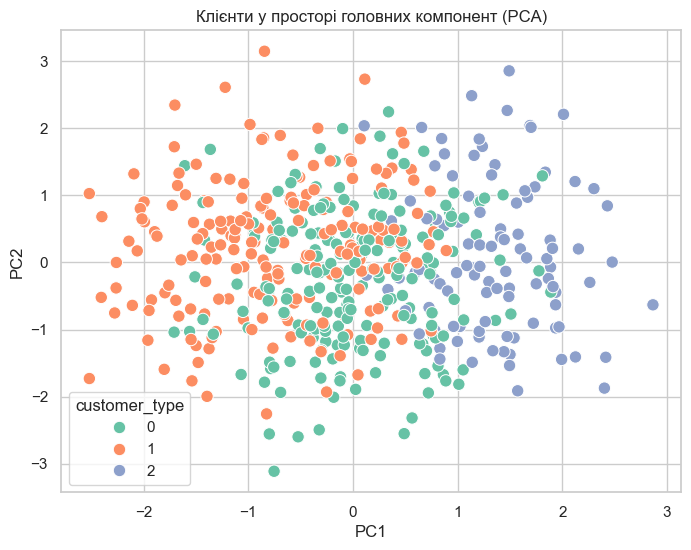

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="customer_type",
    palette="Set2",
    s=80
)
plt.title("Клієнти у просторі головних компонент (PCA)")
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))

Accuracy: 0.7

               precision    recall  f1-score   support

           0       0.66      0.57      0.61        40
           1       0.71      0.78      0.74        37
           2       0.75      0.78      0.77        23

    accuracy                           0.70       100
   macro avg       0.70      0.71      0.71       100
weighted avg       0.70      0.70      0.70       100



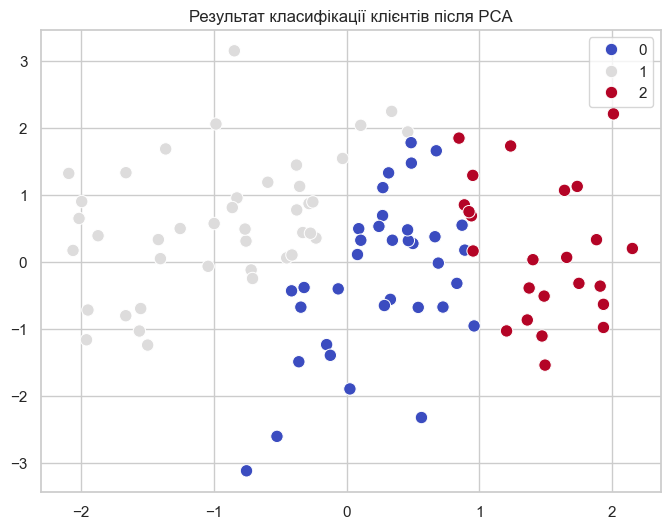

In [7]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_test[:,0],
    y=X_test[:,1],
    hue=y_pred,
    palette="coolwarm",
    s=80
)
plt.title("Результат класифікації клієнтів після PCA")
plt.show()